<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Model_Evaluation_Metric_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification - Model Evaluation Metrics

This google colab notebook explains **how to evaluate a classification model** using:

- Confusion Matrix
- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)
- Accuracy
- Precision
- Recall
- F1-Score
- Classification Report
- Macro Average
- Weighted Average

We will use a simple **Grapes vs Mango** classification example with **Logistic Regression**.

---

## Learning Objectives

By the end of this notebook, you should be able to:

1. Understand what classification means.
2. Train a binary classification model.
3. Understand a confusion matrix.
4. Explain TP, TN, FP, and FN.
5. Calculate Accuracy, Precision, Recall, and F1-Score manually.
6. Calculate metrics for **both classes**.
7. Read and interpret a `classification_report()`.
8. Understand macro average and weighted average.

## 1. What is Classification?

**Classification** is a supervised machine learning task in which a model learns from labeled examples and predicts a **category/class** for new observations.

### Example

Suppose we want to classify a sample as:

- `grapes`
- `mango`

The model learns patterns from the training data and then predicts the class of unseen samples.

### Binary Classification

When there are exactly **two classes**, it is called **binary classification**.

In this notebook:

> **Class 1:** Grapes  
> **Class 2:** Mango

The dataset contains numerical features such as N, P, K, pH, EC, Cu, Fe, Mn, Zn, and B, with `label` as the target.

## 2. Logistic Regression

**Logistic Regression** is a supervised learning algorithm commonly used for classification.

Despite its name, Logistic Regression is primarily a **classification algorithm**.

For binary classification, it estimates the probability of belonging to a class and converts that probability into a class prediction.

Conceptually:

$$
P(y=1 \mid X)
$$

represents the estimated probability that an observation belongs to the positive class.

The model then uses a decision threshold to determine the predicted class.

### Important distinction

- **Training:** The model learns patterns from training data.
- **Prediction:** The model produces class predictions for new/test data.
- **Evaluation:** We compare predictions with the actual labels.

In [52]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## 3. Load the Dataset

The dataset contains **208 observations** and two target classes:

- 104 mango
- 104 grapes

The target column is named `label`.

The other columns are input features used by the model.

In [53]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/democonfusionmatrix.csv"
)

df.head()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B,label
0,98,85,191,6.0,1.45,0.28,14.47,179.63,85.79,47.76,65.83,mango
1,95,87,141,4.8,0.88,0.27,18.63,71.11,64.77,20.86,58.64,mango
2,107,79,127,5.7,0.75,0.25,9.46,80.98,89.12,29.14,60.91,mango
3,123,74,134,6.0,0.83,0.31,19.90,140.22,99.24,23.29,70.52,mango
4,93,73,139,6.4,1.05,0.18,18.34,191.43,54.99,37.53,54.89,mango


In [54]:
df.describe()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,127.278846,62.836538,120.596154,5.914904,0.587933,0.180007,14.567308,118.451827,90.855337,37.724760,49.001106
std,24.994089,19.396006,48.995419,0.556402,0.458865,0.090243,4.701554,40.341585,82.813383,8.524377,15.680833
min,80.000000,24.000000,56.000000,4.500000,0.110000,0.014200,5.000000,50.110000,30.010000,17.990000,4.360000
25%,110.000000,44.750000,79.750000,5.600000,0.170000,0.112750,10.932500,87.397500,60.442500,31.515000,36.895000
50%,126.500000,69.000000,99.500000,6.000000,0.505000,0.170000,14.365000,116.410000,80.075000,38.490000,48.945000
75%,145.000000,80.000000,159.250000,6.300000,0.942500,0.250000,17.970000,144.737500,97.077500,45.142500,62.452500
max,179.000000,95.000000,342.000000,7.200000,1.500000,0.350000,30.010000,255.990000,992.780000,50.000000,74.560000


In [55]:
df["label"].value_counts()

,count
label,
mango,104
grapes,104


### What do we observe?

The dataset is balanced:

- Mango = 104
- Grapes = 104

A balanced class distribution is useful because one class does not dominate the dataset.

## 4. Separate Features and Target

Machine learning separates the dataset into:

### Features — `X`

The input variables used by the model to make predictions.

### Target — `y`

The value that we want the model to predict.

Here, `label` is the target.

Therefore:

$$
X = \text{input features}
$$

$$
y = \text{class label}
$$

In [56]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
     N   P    K   ph    EC     S     Cu      Fe     Mn     Zn      B
0   98  85  191  6.0  1.45  0.28  14.47  179.63  85.79  47.76  65.83
1   95  87  141  4.8  0.88  0.27  18.63   71.11  64.77  20.86  58.64
2  107  79  127  5.7  0.75  0.25   9.46   80.98  89.12  29.14  60.91
3  123  74  134  6.0  0.83  0.31  19.90  140.22  99.24  23.29  70.52
4   93  73  139  6.4  1.05  0.18  18.34  191.43  54.99  37.53  54.89

Target:
0    mango
1    mango
2    mango
3    mango
4    mango
Name: label, dtype: object


## 5. Train-Test Split

We should not evaluate a model only on the data it used for learning.

Instead, we divide the data into:

- **Training set:** used to train the model.
- **Testing set:** used to evaluate the model on unseen data.

Here, `test_size=0.2` means approximately **20%** of the data is reserved for testing.

`random_state=42` makes the split reproducible.

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 166
Testing samples : 42


## 6. Train the Logistic Regression Model

We now create the Logistic Regression model and fit it using the training data.

`max_iter=1000` gives the optimization procedure enough iterations to converge for this dataset.

In [58]:
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## 7. Make Predictions

The trained model can now predict the classes of the unseen test data.

`y_test` contains the **actual labels**.

`y_pred` contains the **predicted labels**.

The evaluation metrics are calculated by comparing these two values.

In [59]:
y_pred = model.predict(X_test)

print("Actual labels:")
print(y_test.to_numpy())

print("\nPredicted labels:")
print(y_pred)

Actual labels:
['grapes' 'mango' 'mango' 'mango' 'grapes' 'mango' 'mango' 'grapes'
 'mango' 'grapes' 'grapes' 'mango' 'grapes' 'grapes' 'grapes' 'grapes'
 'grapes' 'grapes' 'mango' 'mango' 'grapes' 'grapes' 'grapes' 'mango'
 'mango' 'mango' 'mango' 'mango' 'grapes' 'grapes' 'grapes' 'mango'
 'mango' 'grapes' 'grapes' 'mango' 'grapes' 'grapes' 'mango' 'grapes'
 'mango' 'grapes']

Predicted labels:
['grapes' 'mango' 'mango' 'mango' 'grapes' 'mango' 'grapes' 'grapes'
 'mango' 'grapes' 'grapes' 'mango' 'grapes' 'grapes' 'grapes' 'grapes'
 'grapes' 'grapes' 'mango' 'mango' 'grapes' 'grapes' 'grapes' 'grapes'
 'mango' 'mango' 'mango' 'mango' 'grapes' 'grapes' 'grapes' 'mango'
 'mango' 'grapes' 'grapes' 'mango' 'grapes' 'grapes' 'mango' 'grapes'
 'mango' 'grapes']


# 8. Confusion Matrix

A **confusion matrix** is one of the most important tools for evaluating a classification model.

It compares:

- **Actual class**
- **Predicted class**

For a binary classifier, it contains four fundamental outcomes:

| | Predicted Positive | Predicted Negative |
|---|---:|---:|
| **Actual Positive** | TP | FN |
| **Actual Negative** | FP | TN |

### Meaning

**TP — True Positive**  
The model correctly predicts the positive class.

**TN — True Negative**  
The model correctly predicts the negative class.

**FP — False Positive**  
The model predicts the positive class, but the actual class is negative.

**FN — False Negative**  
The model predicts the negative class, but the actual class is positive.

In [60]:
cm = confusion_matrix(y_test, y_pred)

print("Classes:", model.classes_)
print("Confusion Matrix:")
print(cm)

Classes: ['grapes' 'mango']
Confusion Matrix:
[[23  0]
 [ 2 17]]


## 9. Reading Our Confusion Matrix

For this dataset, the class order is:

```text
['grapes', 'mango']
```

The confusion matrix is:

```text
[[23,  0],
 [ 2, 17]]
```

Because rows represent **actual classes** and columns represent **predicted classes**:

| Actual \\ Predicted | Grapes | Mango |
|---|---:|---:|
| **Grapes** | 23 | 0 |
| **Mango** | 2 | 17 |

### Interpretation

- 23 grapes were correctly predicted as grapes.
- 0 grapes were incorrectly predicted as mango.
- 2 mango samples were incorrectly predicted as grapes.
- 17 mango samples were correctly predicted as mango.

For **Grapes as the positive class**:

- TP = 23
- TN = 17
- FP = 2
- FN = 0

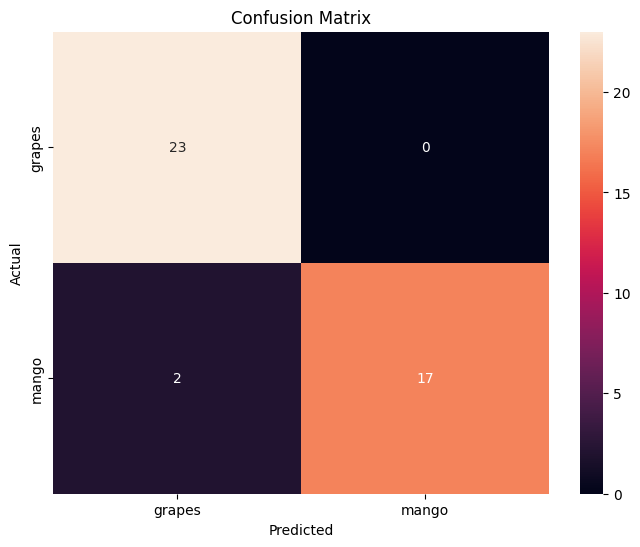

In [61]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 10. Accuracy

## Theory

**Accuracy** tells us the proportion of all predictions that were correct.

### Formula

### Accuracy

$$
Accuracy =
\frac{TP + TN}
{TP + TN + FP + FN}
$$

For our example:

$$
Accuracy =
\frac{23 + 17}
{23 + 17 + 2 + 0}
$$

$$
Accuracy =
\frac{40}{42}
\approx 0.9524
$$

Therefore:

> **Accuracy ≈ 95.24%**

### Simple meaning

Out of 42 test samples, the model correctly classified 40.

In [62]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9523809523809523
Accuracy (%): 95.23809523809523


# 11. Precision

## Theory

**Precision** answers:

> "When the model predicts a particular class, how often is that prediction correct?"

### Formula

### Precision

$$
Precision =
\frac{TP}{TP + FP}
$$

Precision is especially important when **false positives are costly**.

---

## Grapes Precision

For Grapes:

- TP = 23
- FP = 2

## Grapes Precision

When evaluating Grapes as the positive class:

- TP = 23
- FP = 2

$$
Precision_{grapes}
=
\frac{23}{23+2}
=
0.92
$$

So:

> **Grapes Precision = 92%**

---

## Mango Precision

When evaluating Mango as the positive class, the roles are reversed:

- TP = 17
- FP = 0

$$
Precision_{mango}
=
\frac{17}{17+0}
=
1.00
$$

So:

> **Mango Precision = 100%**

### Interpretation

The model was very precise when it predicted **mango**: every sample predicted as mango was actually mango.

In [63]:
# Grapes as the positive class
TP_grapes = 23
FP_grapes = 2

grapes_precision = TP_grapes / (TP_grapes + FP_grapes)

# Mango as the positive class
TP_mango = 17
FP_mango = 0

mango_precision = TP_mango / (TP_mango + FP_mango)

print("Grapes Precision:", grapes_precision)
print("Mango Precision :", mango_precision)

Grapes Precision: 0.92
Mango Precision : 1.0


# 12. Recall

## Theory

**Recall** answers:

> "Out of all the actual samples belonging to a class, how many did the model correctly identify?"

### Formula

### Recall

$$
Recall =
\frac{TP}{TP + FN}
$$

Recall is especially important when **missing a positive case is costly**.

---

## Grapes Recall

For Grapes:

- TP = 23
- FN = 0

$$
Recall_{grapes}
=
\frac{23}{23+0}
=
1.00
$$

So:

> **Grapes Recall = 100%**

The model found all actual grapes.

---

## Mango Recall

For Mango:

- TP = 17
- FN = 2

$$
Recall_{mango}
=
\frac{17}{17+2}
\approx 0.89
$$

So:

> **Mango Recall ≈ 89%**

The model correctly identified 17 out of 19 actual mango samples.

In [64]:
# Grapes
TP_grapes = 23
FN_grapes = 0

grapes_recall = TP_grapes / (TP_grapes + FN_grapes)

# Mango
TP_mango = 17
FN_mango = 2

mango_recall = TP_mango / (TP_mango + FN_mango)

print("Grapes Recall:", grapes_recall)
print("Mango Recall :", mango_recall)

Grapes Recall: 1.0
Mango Recall : 0.8947368421052632


# 13. F1-Score

## Theory

The **F1-score** combines Precision and Recall into a single metric.

It is the **harmonic mean** of Precision and Recall.

### Formula

$$
F1 =
2 \times
\frac{Precision \times Recall}
{Precision + Recall}
$$

A high F1-score means that both Precision and Recall are relatively high.

---

## Grapes F1-Score

$$
F1 =
2 \times
\frac{0.92 \times 1.00}
{0.92 + 1.00}
\approx 0.96
$$

> **Grapes F1-score ≈ 96%**

---

## Mango F1-Score

$$
F1 =
2 \times
\frac{1.00 \times 0.89}
{1.00 + 0.89}
\approx 0.94
$$

> **Mango F1-score ≈ 94%**

In [65]:
grapes_f1 = (
    2 * grapes_precision * grapes_recall
    / (grapes_precision + grapes_recall)
)

mango_f1 = (
    2 * mango_precision * mango_recall
    / (mango_precision + mango_recall)
)

print("Grapes F1-Score:", grapes_f1)
print("Mango F1-Score :", mango_f1)

Grapes F1-Score: 0.9583333333333334
Mango F1-Score : 0.9444444444444444


# 14. Calculate Metrics for Both Classes from the Confusion Matrix

A very important concept is:

> **TP, TN, FP, and FN depend on which class is being treated as the positive class.**

For the confusion matrix:

```text
[[23, 0],
 [ 2,17]]
```

when **Grapes** is the positive class:

```text
TP = 23
TN = 17
FP = 2
FN = 0
```

When **Mango** is the positive class:

```text
TP = 17
TN = 23
FP = 0
FN = 2
```

The safest approach is to derive these values directly from the confusion matrix instead of manually typing them.

In [66]:
# Confusion matrix layout:
# [[actual grapes -> predicted grapes,
#   actual grapes -> predicted mango],
#
#  [actual mango  -> predicted grapes,
#   actual mango  -> predicted mango]]

TP_grapes = cm[0, 0]
FN_grapes = cm[0, 1]
FP_grapes = cm[1, 0]
TN_grapes = cm[1, 1]

# For Mango, treat Mango as the positive class
TP_mango = cm[1, 1]
FN_mango = cm[1, 0]
FP_mango = cm[0, 1]
TN_mango = cm[0, 0]

def calculate_metrics(TP, TN, FP, FN):
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall)
        else 0
    )
    return accuracy, precision, recall, f1

grapes_metrics = calculate_metrics(
    TP_grapes, TN_grapes, FP_grapes, FN_grapes
)

mango_metrics = calculate_metrics(
    TP_mango, TN_mango, FP_mango, FN_mango
)

print("GRAPES")
print("TP:", TP_grapes, "TN:", TN_grapes, "FP:", FP_grapes, "FN:", FN_grapes)
print("Accuracy :", round(grapes_metrics[0], 2))
print("Precision:", round(grapes_metrics[1], 2))
print("Recall   :", round(grapes_metrics[2], 2))
print("F1-Score :", round(grapes_metrics[3], 2))

print("\nMANGO")
print("TP:", TP_mango, "TN:", TN_mango, "FP:", FP_mango, "FN:", FN_mango)
print("Accuracy :", round(mango_metrics[0], 2))
print("Precision:", round(mango_metrics[1], 2))
print("Recall   :", round(mango_metrics[2], 2))
print("F1-Score :", round(mango_metrics[3], 2))

GRAPES
TP: 23 TN: 17 FP: 2 FN: 0
Accuracy : 0.95
Precision: 0.92
Recall   : 1.0
F1-Score : 0.96

MANGO
TP: 17 TN: 23 FP: 0 FN: 2
Accuracy : 0.95
Precision: 1.0
Recall   : 0.89
F1-Score : 0.94


# 15. Classification Report

Scikit-learn provides `classification_report()` to calculate the main classification metrics for every class automatically.

The report contains:

- **Precision**
- **Recall**
- **F1-score**
- **Support**

### What is Support?

**Support** is the number of actual samples belonging to that class in the evaluation dataset.

For this test set:

- Grapes support = 23
- Mango support = 19
- Total support = 42

In [67]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      grapes       0.92      1.00      0.96        23
       mango       1.00      0.89      0.94        19

    accuracy                           0.95        42
   macro avg       0.96      0.95      0.95        42
weighted avg       0.96      0.95      0.95        42



## 16. How to Read the Classification Report

The expected report is approximately:

```text
              precision    recall  f1-score   support

      grapes       0.92      1.00      0.96        23
       mango       1.00      0.89      0.94        19

    accuracy                           0.95        42
   macro avg       0.96      0.95      0.95        42
weighted avg       0.96      0.95      0.95        42
```

### Grapes

- Precision = **0.92**
- Recall = **1.00**
- F1-score = **0.96**
- Support = **23**

The model correctly identified all actual grapes, but 2 mango samples were predicted as grapes.

### Mango

- Precision = **1.00**
- Recall = **0.89**
- F1-score = **0.94**
- Support = **19**

Every sample predicted as mango was actually mango, but 2 actual mango samples were classified as grapes.

# 17. Macro Average

The **macro average** calculates the metric independently for each class and then takes the simple arithmetic mean.

For example:

$$
Macro\ Precision =
\frac{Precision_{grapes}+Precision_{mango}}{2}
$$

$$
=
\frac{0.92+1.00}{2}
=
0.96
$$

### Why is macro average useful?

Macro averaging gives **equal importance to every class**, regardless of how many samples each class contains.

This is especially useful when class performance should be treated equally.

# 18. Weighted Average

The **weighted average** calculates each class's metric and weights it according to its support.

Conceptually:

$$
Weighted\ Average =
\frac{
Metric_1 \times Support_1
+
Metric_2 \times Support_2
}
{Total\ Support}
$$

For this test set:

- Grapes support = 23
- Mango support = 19

Because the class supports are slightly different, the weighted average can differ slightly from the macro average.

### Key difference

**Macro average:** Every class has equal weight.

**Weighted average:** Classes are weighted according to the number of actual samples.

# 19. Accuracy vs Precision vs Recall vs F1-Score

| Metric | Main Question | Important When |
|---|---|---|
| **Accuracy** | How many predictions were correct overall? | Classes are reasonably balanced and error costs are similar |
| **Precision** | When the model predicts a class, how often is it correct? | False positives are important |
| **Recall** | How many actual class samples did the model find? | False negatives are important |
| **F1-score** | How well are Precision and Recall balanced? | Both FP and FN matter |

### Easy way to remember

**Precision → Predicted Positive**

> "Of what I predicted as positive, how much was actually positive?"

**Recall → Actual Positive**

> "Of what was actually positive, how much did I find?"

# 20. Complete Manual Calculation

Using the confusion matrix:

```text
[[23, 0],
 [ 2,17]]
```

## Grapes as Positive

```text
TP = 23
TN = 17
FP = 2
FN = 0
```

### Accuracy

$$
\frac{23+17}{23+17+2+0}=0.9524
$$

### Precision

$$
\frac{23}{23+2}=0.92
$$

### Recall

$$
\frac{23}{23+0}=1.00
$$

### F1-score

$$
2 \times \frac{0.92\times1.00}{0.92+1.00}
\approx0.96
$$

---

## Mango as Positive

```text
TP = 17
TN = 23
FP = 0
FN = 2
```
### Precision

$$
\frac{17}{17+0}=1.00
$$

### Recall

$$
\frac{17}{17+2}\approx0.89
$$

### F1-score

$$
2 \times \frac{1.00\times0.89}{1.00+0.89}
\approx0.94
$$

In [68]:
# Final summary table calculated directly from the confusion matrix

summary = pd.DataFrame({
    "Class": ["grapes", "mango"],
    "Precision": [grapes_metrics[1], mango_metrics[1]],
    "Recall": [grapes_metrics[2], mango_metrics[2]],
    "F1-Score": [grapes_metrics[3], mango_metrics[3]],
    "Support": [
        (y_test == "grapes").sum(),
        (y_test == "mango").sum()
    ]
})

summary.round(2)

,Class,Precision,Recall,F1-Score,Support
0,grapes,0.92,1.00,0.96,23
1,mango,1.00,0.89,0.94,19


# 21. Final Interpretation

For this particular test set:

### Overall Performance

The model achieved approximately:

> **95.24% Accuracy**

That means 40 out of 42 test samples were classified correctly.

### Grapes

- **Precision = 92%**
- **Recall = 100%**
- **F1-score = 96%**

The model did not miss any actual grapes in this test set.

### Mango

- **Precision = 100%**
- **Recall = 89%**
- **F1-score = 94%**

Every sample predicted as mango was correct, but 2 actual mango samples were predicted as grapes.

### Important conclusion

A single metric does not tell the complete story.

Although accuracy is about 95%, the class-wise metrics tell us **where the model makes mistakes**.

That is why a good classification evaluation should examine:

> **Confusion Matrix + Precision + Recall + F1-score + Support**

# 22. Key Takeaways

1. **Classification** predicts a categorical class.
2. A **confusion matrix** shows correct and incorrect predictions.
3. **TP, TN, FP, FN** are the building blocks of classification metrics.
4. **Accuracy** measures overall correctness.
5. **Precision** measures the correctness of positive predictions.
6. **Recall** measures how many actual positives were found.
7. **F1-score** balances Precision and Recall.
8. Metrics must be interpreted **per class**.
9. `classification_report()` provides class-wise and average metrics.
10. **Macro average** treats all classes equally.
11. **Weighted average** accounts for class support.
12. For binary classification, changing the positive class changes the TP/TN/FP/FN perspective.

# 23. Practice Questions

Try answering these before looking at the code again.

### Q1
If:

```text
TP = 80
FP = 20
```

what is Precision?

### Q2
If:

```text
TP = 90
FN = 10
```

what is Recall?

### Q3
What is the difference between Precision and Recall?

### Q4
Why can a model have high Accuracy but poor Recall for one class?

### Q5
For the confusion matrix below:

```text
[[45, 5],
 [ 3,47]]
```

calculate:

- Accuracy
- Precision for the first class
- Recall for the first class
- F1-score for the first class

### Q6
If false negatives are very costly, which metric should receive particular attention?

### Q7
Why should we evaluate both classes instead of looking only at one class?

# 24. One-Page Formula Sheet

## Confusion Matrix

$$
\begin{array}{c|cc}
 & Predicted\ Positive & Predicted\ Negative \\
\hline
Actual\ Positive & TP & FN \\
Actual\ Negative & FP & TN
\end{array}
$$

## Accuracy

$$
Accuracy =
\frac{TP+TN}
{TP+TN+FP+FN}
$$

## Precision

$$
Precision =
\frac{TP}
{TP+FP}
$$

## Recall

$$
Recall =
\frac{TP}
{TP+FN}
$$

## F1-Score

$$
F1 =
2\times
\frac{Precision\times Recall}
{Precision+Recall}
$$

## Macro Average

$$
Macro =
\frac{Metric_1+Metric_2+\cdots+Metric_n}
{n}
$$

## Weighted Average

$$
Weighted =
\frac{
\sum(Metric_i\times Support_i)
}
{\sum Support_i}
$$

---

## Memory Trick

**Precision → "When I predicted positive, was I right?"**

**Recall → "Did I find all the actual positives?"**

**F1 → "How well are Precision and Recall balanced?"**

**Accuracy → "How many predictions were correct overall?"**